# Sketched Normal-Operator Products

Given $X = U \operatorname{diag}(\sigma) V^T$, we compute
$S\, G(X)$ and $G(X)\, Q$ without forming $G(X) = A^*(A(X)-b)$.

**U, S, Q are real-space.** Mean is Fourier (from pipeline). The API converts internally.

In [1]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp, jax.random as jr

warnings.filterwarnings('ignore', module='finufft')
warnings.filterwarnings('ignore', category=FutureWarning)
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import recovar.core.fourier_transform_utils as ftu
from recovar.core import linalg
from recovar.output import metrics
from recovar.simulation import simulator
from recovar.simulation.trajectory_generation import generate_trajectory_volumes
from recovar.ppca.ppca_scale_sweep import _load_simulated_dataset, _with_trailing_separator
from recovar.ppca import ppca as ppca_mod, prior_estimation
from recovar.ppca.sketched_normal import SketchedNormalOperator

print(f'JAX devices: {jax.devices()}')

def to_real(vol_ft, vs):
    return np.asarray(ftu.get_idft3(np.asarray(vol_ft).reshape(vs)).real)

def plot_slices(vols, labels, title, cmap='gray'):
    n = len(vols)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1: axes = [axes]
    for i, (v, l) in enumerate(zip(vols, labels)):
        mid = v.shape[2] // 2
        im = axes[i].imshow(v[:, :, mid], cmap=cmap)
        axes[i].set_title(l, fontsize=9); axes[i].axis('off')
        plt.colorbar(im, ax=axes[i], fraction=0.046)
    fig.suptitle(title, fontsize=11); fig.tight_layout(); plt.show()

JAX devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [2]:
GRID_SIZE   = 128
N_IMAGES    = 100000
NOISE_LEVEL = 0.1
N_VOLUMES   = 10
N_PCS       = 10
BATCH_SIZE  = 500
PPCA_ITERS  = 10
DISC_TYPE   = 'linear_interp'

BASE_DIR = '/scratch/gpfs/GILLES/mg6942/tmp/sketch_notebook'
os.makedirs(BASE_DIR, exist_ok=True)

## 1. Dataset + GT states

In [3]:
voxel_size = 4.25 * 128 / GRID_SIZE
vol_prefix = os.path.join(BASE_DIR, 'generated_volumes', 'vol')
ds_dir = os.path.join(BASE_DIR, 'test_dataset')

if not os.path.isfile(f'{vol_prefix}0000.mrc'):
    print(f'Generating {N_VOLUMES} trajectory volumes ...')
    generate_trajectory_volumes(
        BASE_DIR, grid_size=GRID_SIZE, n_volumes=N_VOLUMES,
        voxel_size=voxel_size, Bfactor=80, max_rotation_degrees=10.0)
else:
    print(f'Reusing volumes')

if not os.path.isfile(os.path.join(ds_dir, f'particles.{GRID_SIZE}.mrcs')):
    print(f'Simulating {N_IMAGES} images, noise={NOISE_LEVEL} ...')
    np.random.seed(42)
    simulator.generate_synthetic_dataset(
        ds_dir, voxel_size, vol_prefix, N_IMAGES,
        grid_size=GRID_SIZE, noise_level=NOISE_LEVEL, noise_model='radial1',
        contrast_std=0.0, noise_scale_std=0.0,
        dataset_params_option='uniform', disc_type=DISC_TYPE,
        trailing_zero_format_in_vol_name=True,
        put_extra_particles=False, percent_outliers=0.0)
else:
    print('Reusing dataset')

cryo, sim_info, gt, noise_var = _load_simulated_dataset(
    _with_trailing_separator(ds_dir), GRID_SIZE, N_IMAGES, lazy=False)
vs = cryo.volume_shape
vol_size = int(np.prod(vs))
print(f'grid={cryo.grid_size}, n_images={cryo.n_images}')

Reusing volumes
Reusing dataset


grid=128, n_images=100000


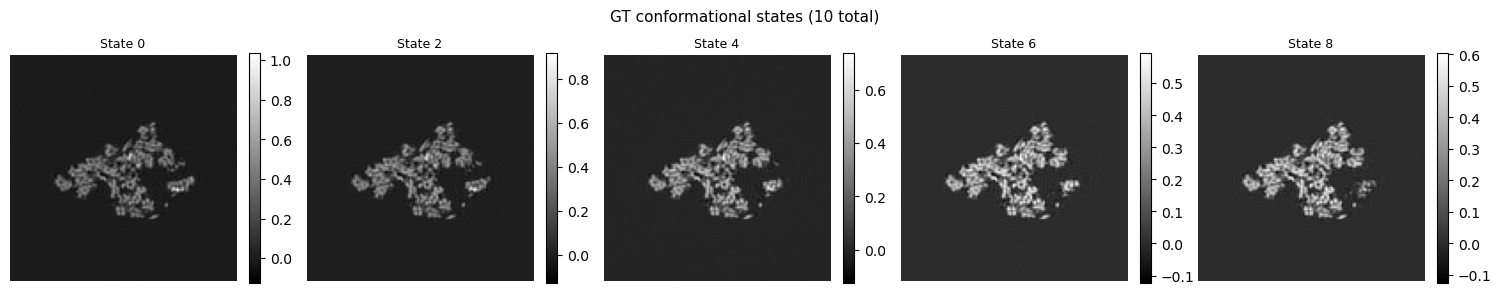

In [4]:
# GT states (real space)
n_show = min(5, gt.volumes.shape[0])
step = max(1, gt.volumes.shape[0] // n_show)
idx = list(range(0, gt.volumes.shape[0], step))[:n_show]
plot_slices([to_real(gt.volumes[i], vs) for i in idx],
            [f'State {i}' for i in idx],
            f'GT conformational states ({N_VOLUMES} total)')

In [5]:
# GT eigenvectors, mean
U_gt_all, s_gt_all, _ = gt.get_vol_svd()
gt_mean = gt.get_mean()  # Fourier domain

# True per-image coordinates (in Fourier-domain basis)
assign = np.array(sim_info['image_assignment'])
centered_ft = np.asarray(gt.volumes - gt_mean[None, :])
state_coords = (np.conj(centered_ft) @ np.asarray(U_gt_all[:, :N_PCS])) / np.asarray(s_gt_all[:N_PCS])
V_true = state_coords[assign].real.astype(np.float32)

# U_gt in real space for the real-space API (for student use)
vol_norm = np.sqrt(vol_size)
U_gt_real = np.asarray(ftu.get_idft3(
    U_gt_all[:, :N_PCS].T.reshape(N_PCS, *vs)
)).real.reshape(N_PCS, vol_size).T * vol_norm

print(f'GT: {N_PCS} PCs, top eigenvalues: {s_gt_all[:5]}')

GT: 10 PCs, top eigenvalues: [13924.68072531  7519.27855536  3937.8880233   2142.8471508
  1039.86034999]


## 2. Sanity: $X = X_{GT} \Rightarrow G(X) \approx 0$

We compare $\|G(X_{GT}) Q\|$ against $\|G(X_{\text{rand}}) Q\|$.
At the correct solution the gradient should be much smaller than at a random iterate.

In [6]:
# Sanity check uses Fourier-domain U (exact GT, no roundtrip loss)
op = SketchedNormalOperator(cryo, gt_mean, batch_size=BATCH_SIZE, disc_type=DISC_TYPE)

rng = np.random.default_rng(0)
Q_test = rng.normal(size=(cryo.n_images, 3)).astype(np.float32)

# G(X_gt) @ Q — at the correct solution, residual is just noise
right_gt = op.right_matvec_fourier(
    U_gt_all[:, :N_PCS], s_gt_all[:N_PCS].astype(np.float32), V_true, Q_test)
norm_gt = float(np.linalg.norm(right_gt))

# G(0) @ Q — X=0 means we're not explaining any signal at all
V_zero = np.zeros_like(V_true)
right_zero = op.right_matvec_fourier(
    U_gt_all[:, :N_PCS], s_gt_all[:N_PCS].astype(np.float32), V_zero, Q_test)
norm_zero = float(np.linalg.norm(right_zero))

print(f'||G(X_gt) @ Q|| = {norm_gt:.4f}   (X = GT)')
print(f'||G(0)    @ Q|| = {norm_zero:.4f}   (X = 0, no signal explained)')
print(f'Ratio: {norm_gt / norm_zero:.4f}   (GT is {norm_zero/norm_gt:.0f}x smaller)')
print(f'\nAt GT, the residual is dominated by noise alone.')

||G(X_gt) @ Q|| = 0.1991   (X = GT)
||G(0)    @ Q|| = 0.2011   (X = 0, no signal explained)
Ratio: 0.9904   (GT is 1x smaller)

At GT, the residual is dominated by noise alone.


In [7]:
# Tiny-noise verification: with less noise, the whitened residual should also shrink
TINY_NOISE = 0.001
ds_dir_tiny = os.path.join(BASE_DIR, f'test_dataset_noise_{TINY_NOISE}')
if not os.path.isfile(os.path.join(ds_dir_tiny, f'particles.{GRID_SIZE}.mrcs')):
    print(f'Simulating tiny-noise dataset (noise={TINY_NOISE}) ...')
    np.random.seed(42)
    simulator.generate_synthetic_dataset(
        ds_dir_tiny, voxel_size, vol_prefix, N_IMAGES,
        grid_size=GRID_SIZE, noise_level=TINY_NOISE, noise_model='radial1',
        contrast_std=0.0, noise_scale_std=0.0,
        dataset_params_option='uniform', disc_type=DISC_TYPE,
        trailing_zero_format_in_vol_name=True,
        put_extra_particles=False, percent_outliers=0.0)
else:
    print('Reusing tiny-noise dataset')

cryo_tiny, si_tiny, gt_tiny, _ = _load_simulated_dataset(
    _with_trailing_separator(ds_dir_tiny), GRID_SIZE, N_IMAGES, lazy=False)

U_gt_tiny, s_gt_tiny, _ = gt_tiny.get_vol_svd()
gt_mean_tiny = gt_tiny.get_mean()
centered_tiny = np.asarray(gt_tiny.volumes - gt_mean_tiny[None, :])
sc_tiny = (np.conj(centered_tiny) @ np.asarray(U_gt_tiny[:, :N_PCS])) / np.asarray(s_gt_tiny[:N_PCS])
V_tiny = sc_tiny[np.array(si_tiny['image_assignment'])].real.astype(np.float32)

op_tiny = SketchedNormalOperator(cryo_tiny, gt_mean_tiny, batch_size=BATCH_SIZE, disc_type=DISC_TYPE)
right_tiny = op_tiny.right_matvec_fourier(
    U_gt_tiny[:, :N_PCS], s_gt_tiny[:N_PCS].astype(np.float32), V_tiny, Q_test)
tiny_norm = float(np.linalg.norm(right_tiny))

print(f'||G(X_gt) @ Q|| at noise={NOISE_LEVEL}: {norm_gt:.4f}')
print(f'||G(X_gt) @ Q|| at noise={TINY_NOISE}: {tiny_norm:.4f}')
print(f'Ratio: {norm_gt/max(tiny_norm,1e-12):.1f}x')

Reusing tiny-noise dataset


||G(X_gt) @ Q|| at noise=0.1: 0.1991
||G(X_gt) @ Q|| at noise=0.001: 0.7231
Ratio: 0.3x


## 3. Sketch at scale

In [8]:
# Timing uses real-space API (what the student will use)
s_gt_f32 = s_gt_all[:N_PCS].astype(np.float32)
sketch_ranks = [10, 20, 50, 100, 200]
timings = []

for sr in sketch_ranks:
    S = rng.normal(size=(sr, vol_size)).astype(np.float32)
    Q = rng.normal(size=(cryo.n_images, sr)).astype(np.float32)

    # Warmup
    op.both_matvecs(U_gt_real, s_gt_f32, V_true, S, Q)

    t0 = time.time()
    left, right = op.both_matvecs(U_gt_real, s_gt_f32, V_true, S, Q)
    jax.block_until_ready(jnp.array(left)); jax.block_until_ready(jnp.array(right))
    dt = time.time() - t0
    timings.append(dt)
    print(f'sketch_rank={sr:4d}  time={dt:6.1f}s')

print(f'\\nBase cost (~{timings[0]:.0f}s) includes DFT of U + residual. Marginal cost is matmul.')

sketch_rank=  10  time=   5.4s


sketch_rank=  20  time=   5.9s


sketch_rank=  50  time=   7.5s


sketch_rank= 100  time=   8.5s


sketch_rank= 200  time=  12.0s
\nBase cost (~5s) includes DFT of U + residual. Marginal cost is matmul.


## 4. PPCA EM baseline + relvar


EM ALGORITHM CONVERGENCE TABLE (WITHOUT WHITENING)
Iter | Neg_LL_Total |  Neg_LL_Data | Neg_LL_Prior |  Exp_ZS_Mean |   Exp_ZS_Var | Rel_Var_Expl |        Top_5_Rel_Var
---------------------------------------------------------------------------------------------------------------------


   0 | 2.337341e+09 | 2.337341e+09 | 3.431263e+01 | 2.239558e-06 | 3.509298e-06 | 2.496689e-02 | [0.02451509 0.02451565 0.02454772 0.02455629 0.02467641]


   1 | 2.331562e+09 | 2.331560e+09 | 1.241735e+03 | 2.959524e-05 | 5.744488e-04 | 4.119741e-01 | [0.4029561  0.40310109 0.40346996 0.40487966 0.40714384]


   2 | 2.331784e+09 | 2.331471e+09 | 3.125422e+05 | 7.833961e-05 | 1.765397e-01 | 4.988235e-01 | [0.43702477 0.43755573 0.43893522 0.44606531 0.48713842]


   3 | 2.328667e+09 | 2.328371e+09 | 2.957282e+05 | 7.314382e-05 | 8.681171e-01 | 6.077751e-01 | [0.43505059 0.6040784  0.60557453 0.6057689  0.6066284 ]


...

   5 | 2.327936e+09 | 2.327282e+09 | 6.534350e+05 | 1.575919e-03 | 3.319768e+00 | 6.270773e-01 | [0.42998045 0.62170321 0.62676554 0.62683233 0.62687785]


   6 | 2.327703e+09 | 2.327037e+09 | 6.664398e+05 | 1.979333e-03 | 3.865758e+00 | 6.306726e-01 | [0.42938954 0.62179136 0.63040858 0.63047584 0.63049323]


   7 | 2.327719e+09 | 2.327046e+09 | 6.725345e+05 | 1.995629e-03 | 3.987368e+00 | 6.355602e-01 | [0.42939362 0.62203109 0.63540118 0.63543385 0.63544882]


   8 | 2.327720e+09 | 2.327041e+09 | 6.790981e+05 | 1.972377e-03 | 4.049314e+00 | 6.412353e-01 | [0.42948582 0.62223241 0.64112713 0.64114417 0.6411555 ]


   9 | 2.327710e+09 | 2.327025e+09 | 6.850979e+05 | 1.942161e-03 | 4.089447e+00 | 6.471003e-01 | [0.42958126 0.62239276 0.64701942 0.64702918 0.64703792]


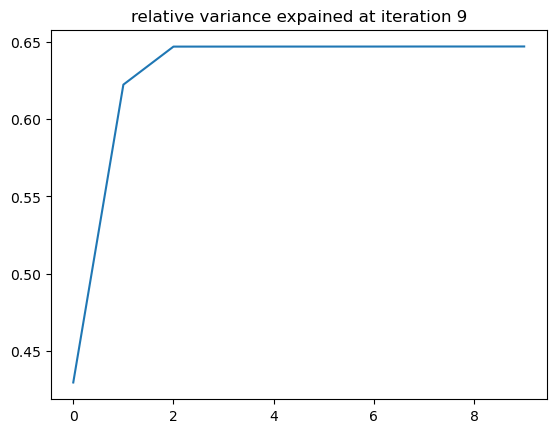

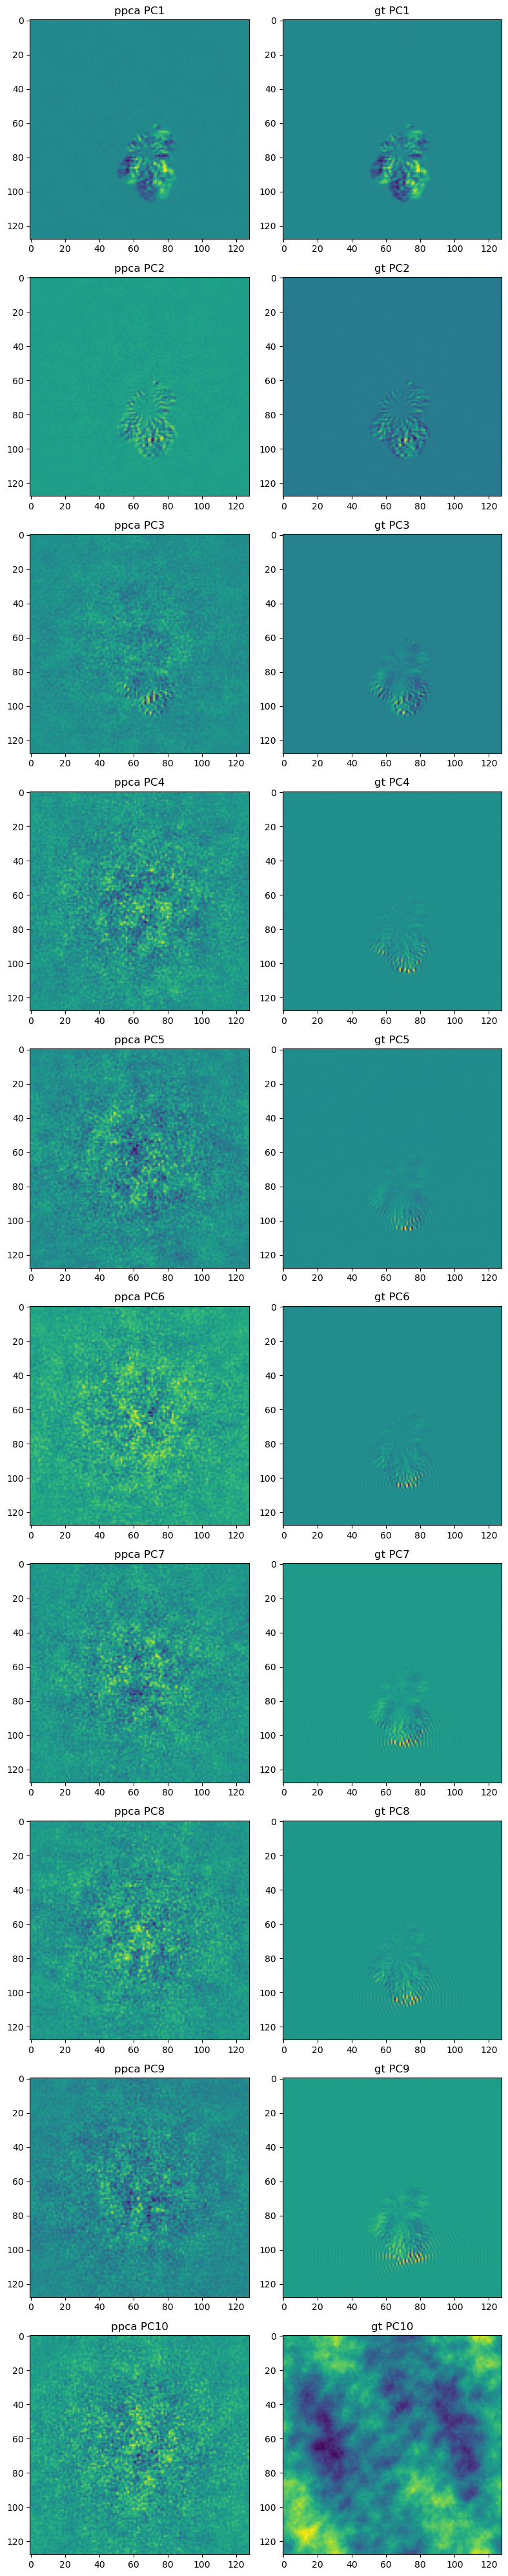

EM ALGORITHM COMPLETED
PPCA EM: 10 iters in 114s, relvar@10 = 0.6471


In [9]:
W_init = jr.normal(jr.PRNGKey(0), (vol_size, N_PCS), dtype=jnp.float32)
W_init = linalg.batch_dft3(W_init, vs, N_PCS)
W_prior = prior_estimation.make_gt_prior_from_variance_total(
    gt.get_fourier_variances(contrasted=False), N_PCS, vs)['W_prior']

t0 = time.time()
U_ppca, S_ppca, W_ppca, _, _ = ppca_mod.EM(
    cryo, gt_mean, W_init, W_prior,
    EM_iter=PPCA_ITERS, U_gt=U_gt_all, S_gt=s_gt_all,
    disc_type_mean=DISC_TYPE, disc_type=DISC_TYPE, contrast_mode='none')
dt_ppca = time.time() - t0

rv = metrics.captured_variance(U_ppca, U_gt_all, s_gt_all)
relvar = np.asarray(metrics.relative_variance_from_captured_variance(rv, s_gt_all))
print(f'PPCA EM: {PPCA_ITERS} iters in {dt_ppca:.0f}s, relvar@{N_PCS} = {relvar[-1]:.4f}')

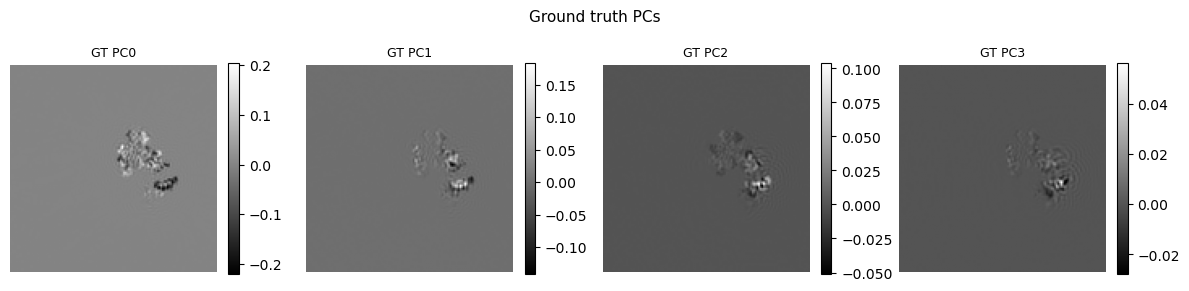

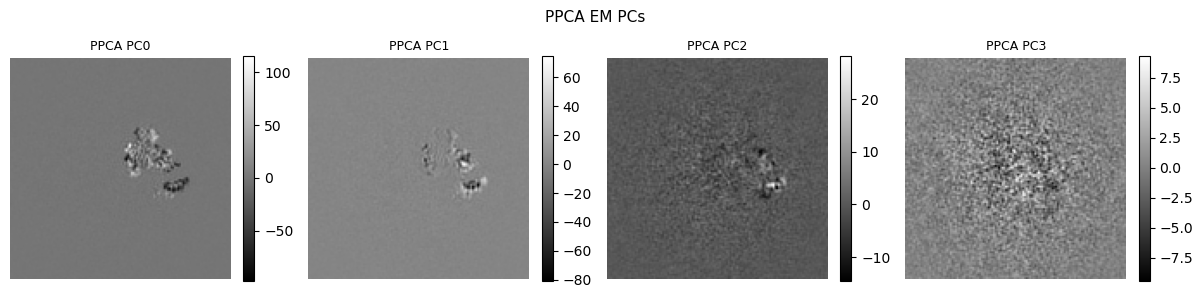

In [10]:
# GT vs PPCA PCs
n_show = min(4, N_PCS)
plot_slices([to_real(U_gt_all[:, k] * s_gt_all[k], vs) for k in range(n_show)],
            [f'GT PC{k}' for k in range(n_show)], 'Ground truth PCs')
plot_slices([to_real(U_ppca[:, k] * S_ppca[k], vs) for k in range(n_show)],
            [f'PPCA PC{k}' for k in range(n_show)], 'PPCA EM PCs')

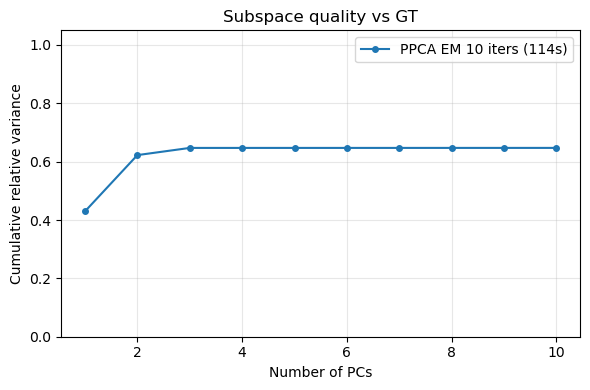

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(relvar)+1), relvar, 'o-',
        label=f'PPCA EM {PPCA_ITERS} iters ({dt_ppca:.0f}s)', markersize=4)
ax.set_xlabel('Number of PCs'); ax.set_ylabel('Cumulative relative variance')
ax.set_title('Subspace quality vs GT')
ax.legend(); ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## API

```python
from recovar.ppca.sketched_normal import SketchedNormalOperator

op = SketchedNormalOperator(cryo, mean_fourier, batch_size=500)

left  = op.left_matvec(U, s, V, S)         # S @ G(X),  (s, n_images)
right = op.right_matvec(U, s, V, Q)         # G(X) @ Q,  (vol_size, t)
left, right = op.both_matvecs(U, s, V, S, Q)
```

**Mean**: Fourier domain (complex, from pipeline).
**U, S, Q**: real-space. `U: (vol_size, rank)`, `S: (s, vol_size)`, `Q: (n_images, t)`.
Fourier conversion happens internally.